In [1]:
!nrnivmodl /home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism
from neuron import h
import plotly.graph_objects as go
import matplotlib.colors as mcolors
from neuron.units import ms, mV
import plotly.io as pio
from matplotlib import pyplot, cm
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import plotly
from neuron import clear_gui_callback
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from scipy.integrate import cumtrapz
from numpy.linalg import pinv, eig
import numpy as np
from multiprocessing import Pool
font2={'family':'Times New Roman',
'weight':'bold',
'size': 10}
# 自定义刻度标签显示格式

from matplotlib.ticker import FuncFormatter
def format_func(value, tick_number):
    return f'{value:.0f}'  # 将刻度值格式化为小数点后两位

def plot_curve(ax2,x,y,color='black',title='', linestyle='-',xlim=[0,100],dx=20,ylim=[0,10],dy=5.0, fontsize=10, alpha = 1.0, xlabel='Time/ms', ylabel = 'Frequency/Hz', label='',ynum_decimals =1):
    if color:
        ax2.plot(x,y,color=color,linewidth=2,linestyle=linestyle,alpha=alpha, label=label)
    else:
        ax2.plot(x,y,linewidth=2,alpha=alpha, linestyle=linestyle,label=label)
    ax2.set_xlabel(xlabel,font2)
    ax2.set_ylabel(ylabel,font2)
    
    # def format_funcx(value, tick_number, num_decimals=xnum_decimals):
    #     if num_decimals==0:
    #         return f'{value:.0f}'
    #     return f'{value:.{num_decimals}f}'

    def format_funcy(value, tick_number, num_decimals=ynum_decimals):
        if num_decimals==0:
          return f'{value:.0f}'
        return f'{value:.{num_decimals}f}'

    # if dx:
    #     ax2.set_xticks(np.arange(xlim[0], xlim[1] + dx, dx))
    #     ax2.set_xticklabels(ax2.get_xticks(), fontsize=fontsize, weight='bold')
    #     ax2.set_xlim([xlim[0], xlim[1]])
    #     ax2.xaxis.set_major_formatter(FuncFormatter(format_funcx))

    if dy:
        ax2.set_yticks(np.arange(ylim[0], ylim[1] + dy, dy))
        ax2.set_yticklabels(ax2.get_yticks(), fontsize=fontsize, weight='bold')
        ax2.set_ylim([ylim[0], ylim[1]])
        ax2.yaxis.set_major_formatter(FuncFormatter(format_funcy))
        
  
    if xlim:
       ax2.set_xticks(np.arange(xlim[0],xlim[1]+dx,dx))
       ax2.set_xticklabels(np.arange(xlim[0],xlim[1]+dx,dx),fontsize=10,weight='bold')
       ax2.set_xlim(xlim)
    # if ylim:
    #    ax2.set_yticks(np.arange(ylim[0],ylim[1]+dy,dy))
    #    ax2.set_yticklabels(np.arange(ylim[0],ylim[1]+dy,dy),fontsize=10,weight='bold')
    #    ax2.set_ylim(ylim)
    if title:
       ax2.set_title('{0}'.format(title),fontsize=12,weight='bold')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    if label:
       ax2.legend(loc='best',prop=font2,edgecolor='white')

h.load_file('nrngui.hoc')
h.load_file("import3d.hoc")

morphologyFilename = "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hoc"
biophysicalModelTemplateFilename = "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/PFCtemplate.hoc"

h.load_file(biophysicalModelTemplateFilename)



/home/wzl/anaconda/envs/neuron9/bin/nrnivmodl:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
INFO : Using neuron-nightly Package (Developer Version)
/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model
cfiles =
Mod files: "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism/ampain.mod" "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism/ampa.mod" "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism/cadynin.mod" "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism/cadyn.mod" "/home/w

--No graphics will be displayed.


1.0

In [2]:
from matplotlib.ticker import FuncFormatter
def format_func(value, tick_number):
    return f'{value:.0f}'  # 将刻度值格式化为小数点后两位
def plot_curve(ax2,x,y,color='black',title='', linestyle='-',linewidth=2, xlim=[0,100],dx=20,
               ylim=[0,10],dy=5.0, fontsize=10, alpha = 1.0, xlabel='Time/ms', 
               ylabel = 'Frequency/Hz', label='',ynum_decimals =1, facecolors='none',
               nonscatter=True, s0=10, facecolor='none'):
    if nonscatter:
        if color:
            ax2.plot(x,y,color=color,linewidth=linewidth,linestyle=linestyle,alpha=alpha, label=label)
        else:
            ax2.plot(x,y,linewidth=linewidth,alpha=alpha, linestyle=linestyle,label=label)
    else:
        if color:
            ax2.scatter(x,y,edgecolors=color,facecolors = facecolor, alpha=alpha, 
                        label=label, s=s0)
        else:
            ax2.scatter(x,y, alpha=alpha, label=label,
                        s=s0)
        
    ax2.set_xlabel(xlabel,font2)
    ax2.set_ylabel(ylabel,font2)
    
    # def format_funcx(value, tick_number, num_decimals=xnum_decimals):
    #     if num_decimals==0:
    #         return f'{value:.0f}'
    #     return f'{value:.{num_decimals}f}'

    def format_funcy(value, tick_number, num_decimals=ynum_decimals):
        if num_decimals==0:
          return f'{value:.0f}'
        return f'{value:.{num_decimals}f}'

    # if dx:
    #     ax2.set_xticks(np.arange(xlim[0], xlim[1] + dx, dx))
    #     ax2.set_xticklabels(ax2.get_xticks(), fontsize=fontsize, weight='bold')
    #     ax2.set_xlim([xlim[0], xlim[1]])
        # ax2.xaxis.set_major_formatter(FuncFormatter(format_funcx))

    if dy:
        ax2.set_yticks(np.arange(ylim[0], ylim[1] + dy, dy))
        ax2.set_yticklabels(ax2.get_yticks(), fontsize=fontsize, weight='bold')
        ax2.set_ylim([ylim[0], ylim[1]])
        ax2.yaxis.set_major_formatter(FuncFormatter(format_funcy))
        
  
    if xlim:
       ax2.set_xticks(np.arange(xlim[0],xlim[1]+dx,dx))
       ax2.set_xticklabels(np.arange(xlim[0],xlim[1]+dx,dx),fontsize=10,weight='bold')
       ax2.set_xlim(xlim)
    # if ylim:
    #    ax2.set_yticks(np.arange(ylim[0],ylim[1]+dy,dy))
    #    ax2.set_yticklabels(np.arange(ylim[0],ylim[1]+dy,dy),fontsize=10,weight='bold')
    #    ax2.set_ylim(ylim)
    if title:
       ax2.set_title('{0}'.format(title),fontsize=12,weight='bold')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    if label:
       ax2.legend(loc='best',prop=font2,edgecolor='white')

# estimate C and GL

In [3]:
def est_GL_C(run_dt):
  
    neuron = h.FScell(morphologyFilename)   
    h.dt = run_dt
    h.tstop = 1000.
    h.v_init = 65.
        
    time = h.Vector().record(h._ref_t)
    recv = h.Vector().record(neuron.soma[0](0.5)._ref_v)
    

    # Initialize voltage clamp
    iclamp = h.IClamp(neuron.soma[0](0.5))
    iclamp.delay = 200.
    iclamp.dur = h.tstop - 500.
    iclamp.amp = 0.
    
    i_clamp = h.Vector().record(iclamp._ref_i)

    # Function to initialize the simulation
    def initialize():
        h.t = 0
        h.finitialize(h.v_init)
        h.fcurrent()

    # Function to integrate the simulation
    def integrate():
        while h.t < h.tstop:
            h.fadvance()

    # Function to run the simulation
    def go():
        initialize()
        integrate()
        
    def verfication(GL, C, t, I):
        
        v = np.zeros(len(t))
        for i in range(len(t)-1):
            v[i+1] = v[i] + run_dt/C*(-GL*v[i]+I[i])
            
        return v
        
        
    # Main simulation loop
    def main():
    
        i_amp = np.arange(1,20)*0.004
        C = np.zeros(len(i_amp))
        GL = np.zeros(len(i_amp))
        iclamp.amp = 0.
        go()
        recv0 = np.array(recv.to_python())
        V_rest = recv0[-1]
        print(V_rest)
        
        for i in range(len(i_amp)):      
            
            iclamp.amp = i_amp[i]
            go()
            recv0 = np.array(recv.to_python())
            i0 = np.array(i_clamp.to_python())
            time0 = np.array(time.to_python())
            plt.plot(time0, recv0-V_rest, color='r')
            recv_norm = recv0 - V_rest
            GL[i] = i_amp[i]*1e-3/recv_norm[7000]
            
            y = np.log(recv_norm[7000:7300])
            A = np.ones((len(time0[7000:7300]),2))
            A[:,0] = time0[7000:7300]
            x, residuals, rank, singular_values = np.linalg.lstsq(A, y, rcond=None)
            tau_decay = -1./x[0] 
            C[i] = tau_decay*GL[i]
            v = verfication(GL[i], C[i], time0, i0*1e-3)
            # v_tune = verfication(0.011, 0.31, time0, i0)
            plt.plot(time0, v, 'b')
            plt.xlim([650,750])
            # plt.plot(time0, v_tune, 'k')
            # plt.legend()
        return  GL,C
    
    GL,C = main()
    return  GL,C

Opening gjhui/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hoc
Denrite No!
1
1
1
0
0
1
1
1
1
1
0
0
0
0
1
1
1
1
1
1
1
1
0
0
0
0
0
1
1
1
0
1
1
1
1
1
1
1
1
0
1
1
1
1
1
1
0
0
0
0
0
0
1
1
1
0
0
0
1
1
1
0
0
1
0
1
1
1
-65.45793039440971
1.0017936585289593e-05
0.0001470913112090827


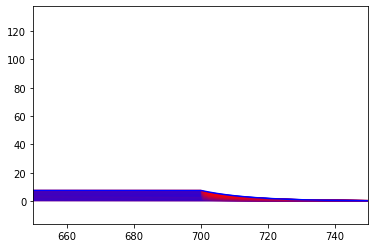

In [4]:
GL,C = est_GL_C(0.1) 
print(np.mean(GL))
print(np.mean(C))

# estimate Ge

Opening gjhui/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hoc
Denrite No!
1
1
1
0
0
1
1
1
1
1
0
0
0
0
1
1
1
1
1
1
1
1
0
0
0
0
0
1
1
1
0
1
1
1
1
1
1
1
1
0
1
1
1
1
1
1
0
0
0
0
0
0
1
1
1
0
0
0
1
1
1
0
0
1
0
1
1
1


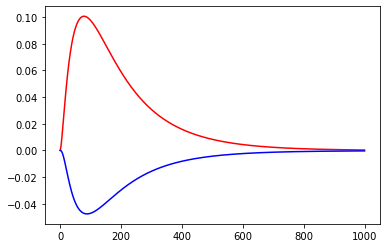

In [55]:
run_dt = 0.1
fE = 5e-5
fI = 5e-5
C = 0.0001470913112090827
GL = 1.0017936585289593e-05
locE = 58
locI = 37
plot = True
    
neuron = h.FScell(morphologyFilename)
    
h.dt = run_dt
h.tstop = 600.

h.v_init = -65.5
Vclamp_init = -65.5
recv = h.Vector().record(neuron.soma[0](0.5)._ref_v)

# Initialize an excitatory and inhibitory synaptic input
# make a new stimulator
stimE = h.NetStim()
stimI = h.NetStim()

synE = h.Exp2Syn(neuron.dend[int(locE)](0.5))
synI = h.Exp2Syn(neuron.dend[int(locI)](0.5))
synE.tau1 = 1.  # ms
synE.tau2 = 5.  # ms
synI.tau1 = 1.  # ms
synI.tau2 = 5.  # ms

synE.e = 0.  # mV for E input and -80 for I input 
synI.e = -100.
    
stimE.number = 1
stimE.start = h.tstop - 100.  # ms
stimI.number = 1
stimI.start = h.tstop - 100.  # ms
ncstimE = h.NetCon(stimE, synE)
ncstimE.delay = 0.
ncstimE.weight[0] = 0e-2  # uS
ncstimI = h.NetCon(stimI, synI)
ncstimI.delay = 0.
ncstimI.weight[0] = 0e-2  # uS


# Initialize voltage clamp
vclamp = h.SEClamp(neuron.soma[0](0.5))
vclamp.amp1 = Vclamp_init
vclamp.dur1 = h.tstop
vclamp.dur2 = h.tstop
vclamp.amp2 = Vclamp_init - 20.

irec = h.Vector()
irec.record(vclamp._ref_i)

# Function to initialize the simulation
def initialize():
    h.t = 0
    h.finitialize(h.v_init)
    h.fcurrent()

# Function to integrate the simulation
def integrate():
    while h.t < h.tstop:
        h.fadvance()

# Function to run the simulation
def go():
    initialize()
    integrate()



Vclamp = np.arange(-110.,-60.,10)
tstart = int(stimI.start/run_dt+1)

#  pure E for the estimation of true GE_est
vclamp.dur1 = 0.
vclamp.dur2 = 0.
vclamp.dur3 = 0.
ncstimE.weight[0] =fE
ncstimI.weight[0] = 0.
go()
recvE0 = np.array(recv.to_python())
V_rest = recvE0[5000]
epsilonE = 0. - V_rest
epsilonI = -100. - V_rest
epsilonI1 = -120. - V_rest


recvE0_norm = recvE0[tstart:tstart+1000] - V_rest
dVdtE = np.diff(recvE0_norm)/run_dt
dVdtE = np.append(dVdtE, 0)
GE_est = (C*dVdtE + GL*recvE0_norm)/(epsilonE - recvE0_norm)

#  pure I input for the estimation of GI_est
vclamp.dur1 = 0.
vclamp.dur2 = 0.
vclamp.dur3 = 0.
ncstimE.weight[0] = 0.
ncstimI.weight[0] = fI
go()
recvI0 = np.array(recv.to_python())
recvI0_norm = recvI0[tstart:tstart+1000] - V_rest
dVdtI = np.diff(recvI0_norm)/run_dt
dVdtI = np.append(dVdtI, 0)
GI_est = (C*dVdtI + GL*recvI0_norm)/(epsilonI - recvI0_norm)
if plot:
    plt.plot(recvE0_norm, 'r')
    plt.plot(recvI0_norm, 'b')



Isyn_inj_t = np.zeros((len(Vclamp),1000))
Isyn_epsilonI1_inj_t = np.zeros((len(Vclamp),1000))
relative_error = np.zeros(4) 



for i in range(len(Vclamp)):
    ncstimE.weight[0] = 0.
    ncstimI.weight[0] = 0.
    vclamp.amp1 = Vclamp[i]
    vclamp.dur1 = h.tstop
    h.v_init = V_rest
    go()
    Iinj0 = np.array(irec.to_python())  # Assuming irec is a NEURON Vector
    
    synE.e = 0.
    synI.e = -100.
    ncstimE.weight[0] = fE
    ncstimI.weight[0] = fI
    vclamp.amp1 = Vclamp[i]
    vclamp.dur1 = h.tstop
    h.v_init = V_rest
    go()
    Iinj1 = np.array(irec.to_python())  # Assuming irec is a NEURON Vector
    Isyn = (Iinj1[tstart:tstart+1000] - Iinj0[tstart:tstart+1000])
    Isyn_inj_t[i,:] = Isyn
    
    synE.e = 0.
    synI.e = -120.
    ncstimE.weight[0] = fE
    ncstimI.weight[0] = fI
    vclamp.amp1 = Vclamp[i]
    vclamp.dur1 = h.tstop
    h.v_init = V_rest
    go()
    Iinj1_epsilonI1 = np.array(irec.to_python())  # Assuming irec is a NEURON Vector
    Isyn_epsilonI1 =  (Iinj1_epsilonI1[tstart:tstart+1000] - Iinj0[tstart:tstart+1000])
    Isyn_epsilonI1_inj_t[i,:] = Isyn_epsilonI1
    
                                                    
traditional_effective_conductance = np.zeros((2,1000))
intercept_effective_conductance = np.zeros((2,1000))
A = np.ones((len(Vclamp),2))
A[:,0] = Vclamp - V_rest
epsilonE = 0. - V_rest
epsilonI = -100. - V_rest
epsilonI1 = -120. - V_rest
for i in range(1000):
    x, residuals, rank, singular_values = np.linalg.lstsq(A, Isyn_inj_t[:,i], 
                                                            rcond=None)
    x_epsilonI1, residuals, rank, singular_values = np.linalg.lstsq(A, 
                        Isyn_epsilonI1_inj_t[:,i], rcond=None)
    
    traditional_effective_conductance[1, i] = (x[0]*epsilonE + x[1])/(epsilonE - epsilonI)
    traditional_effective_conductance[0, i] = (x[0]*epsilonI + x[1])/(epsilonI - epsilonE)
    
    intercept_effective_conductance[1,i] = (x[1] - x_epsilonI1[1])/(epsilonI1 - epsilonI)
    intercept_effective_conductance[0,i] = (-intercept_effective_conductance[1,i]*epsilonI - x[1])/epsilonE

relative_error[0] = np.linalg.norm(GE_est*1e6-intercept_effective_conductance[0,:]*1e3)/np.linalg.norm(GE_est*1e6)
relative_error[1] = np.linalg.norm(GE_est*1e6-traditional_effective_conductance[0,:]*1e3)/np.linalg.norm(GE_est*1e6)
relative_error[2] = np.linalg.norm(GI_est*1e6-intercept_effective_conductance[1,:]*1e3)/np.linalg.norm(GI_est*1e6)
relative_error[3] = np.linalg.norm(GI_est*1e6-traditional_effective_conductance[1,:]*1e3)/np.linalg.norm(GI_est*1e6)

GE_est_norm = GE_est*1e6
GI_est_norm = GI_est*1e6
GE_est_inter = intercept_effective_conductance[0,:]*1e3  
GE_est_trad = traditional_effective_conductance[0,:]*1e3
GI_est_inter = intercept_effective_conductance[1,:]*1e3 
GI_est_trad = traditional_effective_conductance[1,:]*1e3

In [8]:
def error_eff_cond_est_two(run_dt, fE, fI, C=0.00015, GL = 1e-05, locE=58, locI=37,
                         plot =False):
    
    neuron = h.FScell(morphologyFilename)
        
    h.dt = run_dt
    h.tstop = 600.

    h.v_init = -65.5
    Vclamp_init = -65.5
    recv = h.Vector().record(neuron.soma[0](0.5)._ref_v)
    
    # Initialize an excitatory and inhibitory synaptic input
    # make a new stimulator
    stimE = h.NetStim()
    stimI = h.NetStim()

    synE = h.Exp2Syn(neuron.dend[int(locE)](0.5))
    synI = h.Exp2Syn(neuron.dend[int(locI)](0.5))
    synE.tau1 = 1.  # ms
    synE.tau2 = 5.  # ms
    synI.tau1 = 1.  # ms
    synI.tau2 = 5.  # ms

    synE.e = 0.  # mV for E input and -80 for I input 
    synI.e = -100.
        
    stimE.number = 1
    stimE.start = h.tstop - 100.  # ms
    stimI.number = 1
    stimI.start = h.tstop - 100.  # ms
    ncstimE = h.NetCon(stimE, synE)
    ncstimE.delay = 0.
    ncstimE.weight[0] = 0e-2  # uS
    ncstimI = h.NetCon(stimI, synI)
    ncstimI.delay = 0.
    ncstimI.weight[0] = 0e-2  # uS


    # Initialize voltage clamp
    vclamp = h.SEClamp(neuron.soma[0](0.5))
    vclamp.amp1 = Vclamp_init
    vclamp.dur1 = h.tstop
    vclamp.dur2 = h.tstop
    vclamp.amp2 = Vclamp_init - 20.

    irec = h.Vector()
    irec.record(vclamp._ref_i)

    # Function to initialize the simulation
    def initialize():
        h.t = 0
        h.finitialize(h.v_init)
        h.fcurrent()

    # Function to integrate the simulation
    def integrate():
        while h.t < h.tstop:
            h.fadvance()

    # Function to run the simulation
    def go():
        initialize()
        integrate()

    # Main simulation loop
    def main():

        Vclamp = np.arange(-110.,-60.,10)
        tstart = int(stimI.start/run_dt+1)
        
        #  pure E for the estimation of true GE_est
        vclamp.dur1 = 0.
        vclamp.dur2 = 0.
        vclamp.dur3 = 0.
        ncstimE.weight[0] = fE
        ncstimI.weight[0] = 0.
        go()
        recvE0 = np.array(recv.to_python())
        V_rest = recvE0[tstart]
        recvE0_norm = recvE0[tstart:tstart + 1000] - V_rest
        epsilonE = 0. - V_rest
        epsilonI = -100. - V_rest
        epsilonI1 = -120. - V_rest
        dVdtE = np.diff(recvE0_norm)/run_dt
        dVdtE = np.append(dVdtE, 0)
        GE_est = (C*dVdtE + GL*recvE0_norm)/(epsilonE - recvE0_norm)
        
        #  pure I input for the estimation of GI_est
        vclamp.dur1 = 0.
        vclamp.dur2 = 0.
        vclamp.dur3 = 0.
        ncstimE.weight[0] = 0.
        ncstimI.weight[0] = fI
        go()
        recvI0 = np.array(recv.to_python())
        recvI0_norm = recvI0[tstart:tstart+1000] - V_rest
        dVdtI = np.diff(recvI0_norm)/run_dt
        dVdtI = np.append(dVdtI, 0)
        GI_est = (C*dVdtI + GL*recvI0_norm)/(epsilonI - recvI0_norm)
        if plot:
            plt.plot(recvE0_norm, 'r')
            plt.plot(recvI0_norm, 'b')
        
        
    
        Isyn_inj_t = np.zeros((len(Vclamp),1000))
        Isyn_epsilonI1_inj_t = np.zeros((len(Vclamp),1000))
        relative_error = np.zeros(4) 

        

        for i in range(len(Vclamp)):
            ncstimE.weight[0] = 0.
            ncstimI.weight[0] = 0.
            vclamp.amp1 = Vclamp[i]
            vclamp.dur1 = h.tstop
            h.v_init = V_rest
            go()
            Iinj0 = np.array(irec.to_python())  # Assuming irec is a NEURON Vector
            
            synE.e = 0.
            synI.e = -100.
            ncstimE.weight[0] = fE
            ncstimI.weight[0] = fI
            vclamp.amp1 = Vclamp[i]
            vclamp.dur1 = h.tstop
            h.v_init = V_rest
            go()
            Iinj1 = np.array(irec.to_python())  # Assuming irec is a NEURON Vector
            Isyn = (Iinj1[tstart:tstart+1000] - Iinj0[tstart:tstart+1000])
            Isyn_inj_t[i,:] = Isyn
            
            synE.e = 0.
            synI.e = -120.
            ncstimE.weight[0] = fE
            ncstimI.weight[0] = fI
            vclamp.amp1 = Vclamp[i]
            vclamp.dur1 = h.tstop
            h.v_init = V_rest
            go()
            Iinj1_epsilonI1 = np.array(irec.to_python())  # Assuming irec is a NEURON Vector
            Isyn_epsilonI1 =  (Iinj1_epsilonI1[tstart:tstart+1000] - Iinj0[tstart:tstart+1000])
            Isyn_epsilonI1_inj_t[i,:] = Isyn_epsilonI1
            
                                                         
        traditional_effective_conductance = np.zeros((2,1000))
        intercept_effective_conductance = np.zeros((2,1000))
        A = np.ones((len(Vclamp),2))
        A[:,0] = Vclamp - V_rest
        epsilonE = 0. - V_rest
        epsilonI = -100. - V_rest
        epsilonI1 = -120. - V_rest
        for i in range(1000):
            x, residuals, rank, singular_values = np.linalg.lstsq(A, Isyn_inj_t[:,i], 
                                                                  rcond=None)
            x_epsilonI1, residuals, rank, singular_values = np.linalg.lstsq(A, 
                                Isyn_epsilonI1_inj_t[:,i], rcond=None)
            
            traditional_effective_conductance[1, i] = (x[0]*epsilonE + x[1])/(epsilonE - epsilonI)
            traditional_effective_conductance[0, i] = (x[0]*epsilonI + x[1])/(epsilonI - epsilonE)
           
            intercept_effective_conductance[1,i] = (x[1] - x_epsilonI1[1])/(epsilonI1 - epsilonI)
            intercept_effective_conductance[0,i] = (-intercept_effective_conductance[1,i]*epsilonI - x[1])/epsilonE
        
        relative_error[0] = np.linalg.norm(GE_est*1e6-intercept_effective_conductance[0,:]*1e3)/np.linalg.norm(GE_est*1e6)
        relative_error[1] = np.linalg.norm(GE_est*1e6-traditional_effective_conductance[0,:]*1e3)/np.linalg.norm(GE_est*1e6)
        relative_error[2] = np.linalg.norm(GI_est*1e6-intercept_effective_conductance[1,:]*1e3)/np.linalg.norm(GI_est*1e6)
        relative_error[3] = np.linalg.norm(GI_est*1e6-traditional_effective_conductance[1,:]*1e3)/np.linalg.norm(GI_est*1e6)
        
        GE_est_norm = GE_est*1e6
        GI_est_norm = GI_est*1e6
        GE_est_inter = intercept_effective_conductance[0,:]*1e3  
        GE_est_trad = traditional_effective_conductance[0,:]*1e3
        GI_est_inter = intercept_effective_conductance[1,:]*1e3 
        GI_est_trad = traditional_effective_conductance[1,:]*1e3 
        
        return relative_error, GE_est_norm, GI_est_norm, GE_est_inter, GE_est_trad, GI_est_inter, GI_est_trad
    
    
    relative_error, GE_est_norm, GI_est_norm, GE_est_inter, GE_est_trad, GI_est_inter, GI_est_trad= main()
    N = len(relative_error) + len(GE_est_norm) + len(GI_est_norm) + len(GE_est_inter) + len(GE_est_trad) + len(GI_est_inter) + len(GI_est_trad)
    N1 = len(relative_error)
    N2 = N1 + len(GE_est_norm)
    N3 = N2 + len(GI_est_norm)
    N4 = N3 + len(GE_est_inter)
    N5 = N4 + len(GE_est_trad)
    N6 = N5 + len(GI_est_inter)
    N7 = N6 + len(GI_est_trad)
    results = np.zeros(N)
    results[:N1] = relative_error
    results[N1:N2] = GE_est_norm
    results[N2:N3] = GI_est_norm
    results[N3:N4] = GE_est_inter
    results[N4:N5] = GE_est_trad
    results[N5:N6] = GI_est_inter
    results[N6:N7] = GI_est_trad
    return results

Opening gjhui/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hoc
Denrite No!
1
1
1
0
0
1
1
1
1
1
0
0
0
0
1
1
1
1
1
1
1
1
0
0
0
0
0
1
1
1
0
1
1
1
1
1
1
1
1
0
1
1
1
1
1
1
0
0
0
0
0
0
1
1
1
0
0
0
1
1
1
0
0
1
0
1
1
1


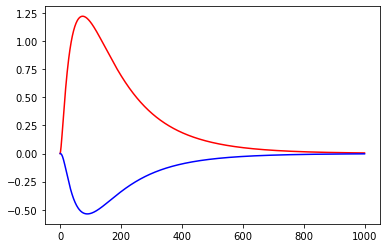

In [21]:
results = error_eff_cond_est_two(0.1, 60e-5, 60e-5, C=0.0001470913112090827, GL=1.0017936585289593e-05, 
                        locE=27, locI=37, plot = True)

In [23]:
GE_est_norm = results[4:1004]
GI_est_norm = results[1004:2004]
GE_est_inter = results[2004:3004]
GE_est_trad = results[3004:4004]
GI_est_inter = results[4004:5004]
GI_est_trad = results[5004:6004]

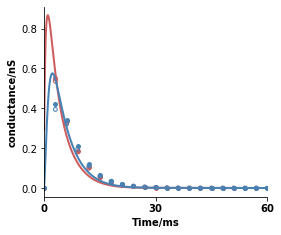

In [24]:
time = np.arange(0,len(GE_est_norm))*0.1
s0 = 15
fig, ax2 = plt.subplots(1,1, figsize = (4,3.5))
plot_curve(ax2,time, GE_est_norm, color='indianred', label='',
               xlim=[0,100], dx=50, linewidth=2, 
               ylim=[0, 2], dy=0., ynum_decimals=0, ylabel='conductance/nS')

plot_curve(ax2,time[::30], GE_est_inter[::30], color='indianred',label='',
               xlim=[0,100], dx=50,
               ylim=[0, 2], dy=0., ynum_decimals=0, ylabel='conductance/nS',
               nonscatter=False, s0=s0, facecolor='indianred')

plot_curve(ax2, time[::30], GE_est_trad[::30], color='indianred',label='',
               xlim=[0,60], dx=30,
               ylim=[-0.3, 1.5], dy = 0., ynum_decimals=1, ylabel='conductance/nS',
               nonscatter=False, s0=s0, facecolor='none')

plot_curve(ax2,time, GI_est_norm,color='steelblue',label='',
               xlim=[0,100], dx=50,linewidth=2, 
               ylim=[0, 2], dy=0., ynum_decimals=0, ylabel='conductance/nS')

plot_curve(ax2, time[::30], GI_est_inter[::30], color='steelblue',label='',
               xlim=[0,100], dx=50,
               ylim=[0, 2], dy=0., ynum_decimals=0, ylabel='conductance/nS',
               nonscatter=False, s0=s0, facecolor='steelblue')

plot_curve(ax2, time[::30], GI_est_trad[::30],color='steelblue',label='',
               xlim=[0,60], dx=30,
               ylim=[-0.3, 1.5], dy = 0., ynum_decimals=1, ylabel='conductance/nS',
               nonscatter=False, s0=s0, facecolor='none')
# plt.savefig("/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/L5PC_neuron/figure/figure4/pairEI_eff_con.eps", format='eps', dpi=300)
plt.show()
# ax2[1].set_title('active I')

In [16]:
# Your existing functions and code
def error_eff_cond_est_two_parallel(args,):
    stimu0, = args
    results = error_eff_cond_est_two(0.1, 7e-5, 7e-5, C=0.0001470913112090827, GL=1.0017936585289593e-05,
            plot = False, locE = stimu0[0], locI = stimu0[1])
     
    return results
loc = np.arange(0,68,1)
# 生成网格
X, Y = np.meshgrid(loc, loc)

# 将网格重塑为9x9的数组
# 首先将X和Y平铺为一维数组，然后将这两个数组堆叠成二维数组，每一行是一个(x,y)对
stimu = np.vstack([X.ravel(), Y.ravel()]).T



# Create a Pool with desired number of processes (adjust as needed)
num_processes = 55
with Pool(num_processes) as pool:
    # Prepare arguments for parallel processing
    args_list = [(stimu0,) for stimu0 in stimu]

    # Apply the function in parallel
    results = pool.map(error_eff_cond_est_two_parallel, args_list)

results_total = np.zeros((len(stimu), 6004))

for i, result in enumerate(results):
    results_total[i, :] = result
np.savetxt("pair_eff_cond_E7e5_I7e5_whole.txt", results_total)

Opening gjhuiOpening gjhuiOpening gjhui/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hoc/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hocOpening gjhuiOpening gjhuiOpening gjhuiOpening gjhui
/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hoc
Opening gjhuiOpening gjhui/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hocOpening gjhuiOpening gjhui/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model

In [33]:
loc=np.arange(0, 1599, 1)
# 生成网格
X, Y = np.meshgrid(loc, loc)

# 将网格重塑为9x9的数组
# 首先将X和Y平铺为一维数组，然后将这两个数组堆叠成二维数组，每一行是一个(x,y)对
stimu = np.vstack([X.ravel(), Y.ravel()]).T
print(len(stimu))
print(1599*1599)

2556801
2556801


In [3]:
results_total = np.loadtxt("pair_eff_cond_E7e5_I7e5_whole.txt")
relative_error = results_total[:, :4]
GE_est_norm = results_total[:, 4:1004]
GI_est_norm = results_total[:, 1004:2004]
GE_est_inter = results_total[:, 2004:3004]
GE_est_trad = results_total[:, 3004:4004]
GI_est_inter = results_total[:, 4004:5004]
GI_est_trad = results_total[:, 5004:6004]
relative_error_mean = np.mean(relative_error,axis=0)
GE_est_inter_mean = np.mean(GE_est_inter, axis=1)
GE_est_norm_mean = np.mean(GE_est_norm, axis=1)
GI_est_norm_mean = np.mean(GI_est_norm, axis=1)
GE_est_trad_mean = np.mean(GE_est_trad, axis=1)
GI_est_inter_mean = np.mean(GI_est_inter, axis=1)
GI_est_trad_mean = np.mean(GI_est_trad, axis=1)
negative_GE_est_inter = np.sum(GE_est_inter_mean<0)
negative_GE_est_trad = np.sum(GE_est_trad_mean<0)
negative_GI_est_inter = np.sum(GI_est_inter_mean<0)
negative_GI_est_trad = np.sum(GI_est_trad_mean<0)
negative_GE_est_norm = np.sum(GE_est_norm_mean<0)
negative_GI_est_norm = np.sum(GI_est_norm_mean<0)
# mean error
error_mean = np.zeros_like(relative_error)
error_mean[:,0] = np.abs(np.mean(GE_est_norm,axis=1) - np.mean(GE_est_inter, axis=1))/np.mean(GE_est_norm,axis=1)
error_mean[:,1] = np.abs(np.mean(GE_est_norm,axis=1) - np.mean(GE_est_trad, axis=1))/np.mean(GE_est_norm,axis=1)
error_mean[:,2] = np.abs(np.mean(GI_est_norm,axis=1) - np.mean(GI_est_inter, axis=1))/np.mean(GI_est_norm,axis=1)
error_mean[:,3] = np.abs(np.mean(GI_est_norm,axis=1) - np.mean(GI_est_trad, axis=1))/np.mean(GI_est_norm,axis=1)

print(np.mean(error_mean,axis=0))


[0.04594369 0.07383728 0.08438174 0.15158468]


In [4]:
print(np.max(error_mean,axis=0))

[0.0607826  0.11811987 0.11216545 0.24265908]


(4624, 4)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


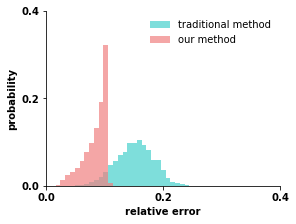

In [12]:
# distance = np.loadtxt('pairEI_distance.txt')
# relative_error = np.loadtxt('pair_eff_cond_relative_error_E6e3_I3e3_whole.txt')

error = error_mean
# print(np.shape(distance))
print(np.shape(error))
fontsize = 10
bins = np.linspace(0,0.4,50)
fig, ax1 = plt.subplots(1,1,figsize=(4,3), constrained_layout=True)
nE_our,binsE_our = np.histogram(error[:,2],bins=bins)
nE_trad,binsE_trad = np.histogram(error[:,3],bins=bins)
widths = bins[2]-bins[1]
ax1.bar(bins[:-1], nE_trad/np.sum(nE_trad), zorder=1, align='edge', width=widths, 
        color='mediumturquoise',alpha=0.7, edgecolor = None,  linewidth=1,label='traditional method')
ax1.bar(bins[:-1], nE_our/np.sum(nE_our), zorder=1, align='edge', width=widths,
        color='lightcoral',alpha=0.7, edgecolor = None,  linewidth=1,label='our method')


ax1.set_xlabel('relative error',fontsize=fontsize,weight='bold')
ax1.set_ylabel('probability',fontsize=fontsize,weight='bold')
ax1.set_xticks(np.arange(0,0.5,0.2))
ax1.set_yticks(np.arange(0,0.5,0.2))
ax1.set_xticklabels(np.arange(0,0.5,0.2),fontsize=fontsize,weight='bold')
ax1.set_yticklabels(np.arange(0,0.5,0.2),fontsize=fontsize,weight='bold')
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.set_ylim([0,0.4])
ax1.set_xlim([0,0.4])
ax1.legend(loc='best',fontsize=fontsize,edgecolor='white')
# ax1.set_title('E',fontsize=fontsize,weight='bold')
plt.savefig('relative_error_eff_con_I.eps')

(4624, 4)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


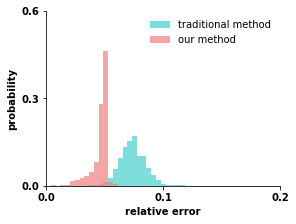

In [19]:
# distance = np.loadtxt('pairEI_distance.txt')
# relative_error = np.loadtxt('pair_eff_cond_relative_error_E6e3_I3e3_whole.txt')

error = error_mean
# print(np.shape(distance))
print(np.shape(error))
fontsize = 10
bins = np.linspace(0,0.2,50)
fig, ax1 = plt.subplots(1,1,figsize=(4,3), constrained_layout=True)
nE_our,binsE_our = np.histogram(error[:,0],bins=bins)
nE_trad,binsE_trad = np.histogram(error[:,1],bins=bins)
widths = bins[2]-bins[1]
ax1.bar(bins[:-1], nE_trad/np.sum(nE_trad), zorder=1, align='edge', width=widths, 
        color='mediumturquoise',alpha=0.7, edgecolor = None,  linewidth=1,label='traditional method')
ax1.bar(bins[:-1], nE_our/np.sum(nE_our), zorder=1, align='edge', width=widths,
        color='lightcoral',alpha=0.7, edgecolor = None,  linewidth=1,label='our method')


ax1.set_xlabel('relative error',fontsize=fontsize,weight='bold')
ax1.set_ylabel('probability',fontsize=fontsize,weight='bold')
ax1.set_xticks(np.arange(0,0.5,0.1))
ax1.set_yticks(np.arange(0,0.7,0.3))
ax1.set_xticklabels(np.arange(0,0.5,0.1),fontsize=fontsize,weight='bold')
ax1.set_yticklabels(np.arange(0,0.7,0.3),fontsize=fontsize,weight='bold')
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.set_ylim([0,0.6])
ax1.set_xlim([0,0.2])
ax1.legend(loc='best',fontsize=fontsize,edgecolor='white')
# ax1.set_title('E',fontsize=fontsize,weight='bold')
plt.savefig('relative_error_eff_con_E.eps')

In [6]:
# y_values = np.array([negative_GE_est_inter, negative_GE_est_trad])/len(GE_est_inter_mean)

y_values = np.array([negative_GI_est_inter, negative_GI_est_trad])/len(GI_est_inter_mean)
print(y_values)

[0. 0.]


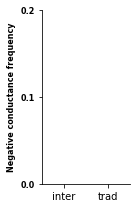

In [20]:
import matplotlib.pyplot as plt


# y_values = np.array([negative_GI_est_inter, negative_GI_est_trad])/len(GI_est_inter_mean)
x_values = ['inter', 'trad']
y_values = np.array([negative_GE_est_inter, negative_GE_est_trad])/len(GE_est_inter_mean)


# 指定每个条形的位置
positions = [1.5, 2.5]  # 注意x1和x2之间的距离小于x2和x3之间的距离

fig, ax = plt.subplots(1,1, figsize = (2,3))
ax.bar(positions, y_values, tick_label=x_values, color = ['lightcoral',  'mediumturquoise'],width=0.5)

# 添加标签和标题
# plt.xlabel('Variables')
ylim=[0,0.2]
dy=0.1
fontsize=8
ynum_decimals = 1
ax.set_ylabel('Negative conductance frequency', fontsize=fontsize, weight='bold')
ax.set_yticks(np.arange(ylim[0], ylim[1] + dy, dy))
ax.set_yticklabels(ax.get_yticks(), fontsize=fontsize, weight='bold')
ax.set_ylim([ylim[0], ylim[1]])
ax.set_xlim([1, 3])
def format_funcy(value, tick_number, num_decimals=ynum_decimals):
    if num_decimals==0:
        return f'{value:.0f}'
    return f'{value:.{num_decimals}f}'
ax.yaxis.set_major_formatter(FuncFormatter(format_funcy))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("negative_distr_E.eps", format='eps', dpi=300)


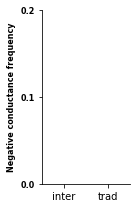

In [21]:
import matplotlib.pyplot as plt


y_values = np.array([negative_GI_est_inter, negative_GI_est_trad])/len(GI_est_inter_mean)
x_values = ['inter', 'trad']
# y_values = np.array([negative_GE_est_inter, negative_GE_est_trad])/len(GE_est_inter_mean)


# 指定每个条形的位置
positions = [1.5, 2.5]  # 注意x1和x2之间的距离小于x2和x3之间的距离

fig, ax = plt.subplots(1,1, figsize = (2,3))
ax.bar(positions, y_values, tick_label=x_values, color = ['lightcoral',  'mediumturquoise'],width=0.5)

# 添加标签和标题
# plt.xlabel('Variables')
ylim=[0,0.2]
dy=0.1
fontsize=8
ynum_decimals = 1
ax.set_ylabel('Negative conductance frequency', fontsize=fontsize, weight='bold')
ax.set_yticks(np.arange(ylim[0], ylim[1] + dy, dy))
ax.set_yticklabels(ax.get_yticks(), fontsize=fontsize, weight='bold')
ax.set_ylim([ylim[0], ylim[1]])
ax.set_xlim([1, 3])
def format_funcy(value, tick_number, num_decimals=ynum_decimals):
    if num_decimals==0:
        return f'{value:.0f}'
    return f'{value:.{num_decimals}f}'
ax.yaxis.set_major_formatter(FuncFormatter(format_funcy))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("negative_distr_I.eps", format='eps', dpi=300)


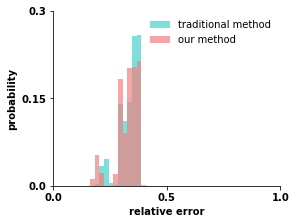

In [28]:
fontsize = 10
bins = np.linspace(0,1,50)
fig, ax1 = plt.subplots(1,1,figsize=(4,3), constrained_layout=True)
nE_our,binsE_our = np.histogram(relative_error[:,0],bins=bins)
nE_trad,binsE_trad = np.histogram(relative_error[:,1],bins=bins)
widths = bins[2]-bins[1]
ax1.bar(bins[:-1], nE_trad/np.sum(nE_trad), zorder=1, align='edge', width=widths, 
        color='mediumturquoise',alpha=0.7, edgecolor = None,  linewidth=1,label='traditional method')
ax1.bar(bins[:-1], nE_our/np.sum(nE_our), zorder=1, align='edge', width=widths,
        color='lightcoral',alpha=0.7, edgecolor = None,  linewidth=1,label='our method')


ax1.set_xlabel('relative error',fontsize=fontsize,weight='bold')
ax1.set_ylabel('probability',fontsize=fontsize,weight='bold')
ax1.set_xticks(np.arange(0,1.2,0.5))
ax1.set_yticks(np.arange(0,0.4,0.15))
ax1.set_xticklabels(np.arange(0,1.2,0.5),fontsize=fontsize,weight='bold')
ax1.set_yticklabels(np.arange(0,0.4,0.15),fontsize=fontsize,weight='bold')
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.set_ylim([0,0.3])
ax1.set_xlim([0,1])
ax1.legend(loc='best',fontsize=fontsize,edgecolor='white')
# ax1.set_title('E',fontsize=fontsize,weight='bold')
# plt.savefig('relative_error_eff_con_I.eps')

In [25]:
def caculate_distance(locnumE):
     
    L5PC = h.FScell(morphologyFilename)
    x_soma = (L5PC.soma[0].x3d(0)+ L5PC.soma[0].x3d(1))/2.
    y_soma = (L5PC.soma[0].y3d(0)+ L5PC.soma[0].y3d(1))/2.
    z_soma = (L5PC.soma[0].z3d(0)+ L5PC.soma[0].z3d(1))/2.

    x_synE = (L5PC.dend[int(locnumE)].x3d(0)+ L5PC.dend[int(locnumE)].x3d(1))/2.
    y_synE = (L5PC.dend[int(locnumE)].y3d(0)+ L5PC.dend[int(locnumE)].y3d(1))/2.
    z_synE = (L5PC.dend[int(locnumE)].z3d(0)+ L5PC.dend[int(locnumE)].z3d(1))/2.
 
        
    distance = np.sqrt((x_soma-x_synE)**2 + (y_soma-y_synE)**2 + (z_soma-z_synE)**2)
    
    return distance

In [4]:
def caculate_distance_parallel(args,):
    loc0, = args
    distance = caculate_distance(loc0)      
    return distance

loc = np.arange(0,68,1)
distance = np.zeros(len(loc))
# Create a Pool with desired number of processes (adjust as needed)
num_processes = 55
with Pool(num_processes) as pool:
    # Prepare arguments for parallel processing
    args_list = [(loc0,) for loc0 in loc]

    # Apply the function in parallel
    results = pool.map(caculate_distance_parallel, args_list)

distance = results

Opening gjhuiOpening gjhuiOpening gjhuiOpening gjhuiOpening gjhuiOpening gjhui/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hocOpening gjhuiOpening gjhuiOpening gjhuiOpening gjhuiOpening gjhuiOpening gjhuiOpening gjhuiOpening gjhui/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hocOpening gjhui/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hocOpening gjhui/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hoc/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSB

In [22]:
np.savetxt('dend_distance.txt', distance)

In [29]:
print(np.max(distance))

31.240386888074188
